<a href="https://colab.research.google.com/github/sanjivinicarmel/AgriDataAnalysis2016/blob/main/ResNet50_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Checking GPU
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []


In [ ]:
# Install required libraries
!pip install kaggle
!pip install seaborn

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sanjivini","key":"4642cb0cc987eb00bf86409e56446016"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:09<00:00, 65.0MB/s]



In [ ]:
import zipfile #Unzipping the dataset

with zipfile.ZipFile("gtsrb-german-traffic-sign.zip","r") as zip_ref:
    zip_ref.extractall("/content/GTSRB")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
train_path="/content/GTSRB/Train"

In [ ]:
#Dataset Preprocessing
IMAGE_SIZE=(224,224)

BATCH_SIZE=32

train_datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator=train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode="categorical"
)

validation_generator=train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical"
)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


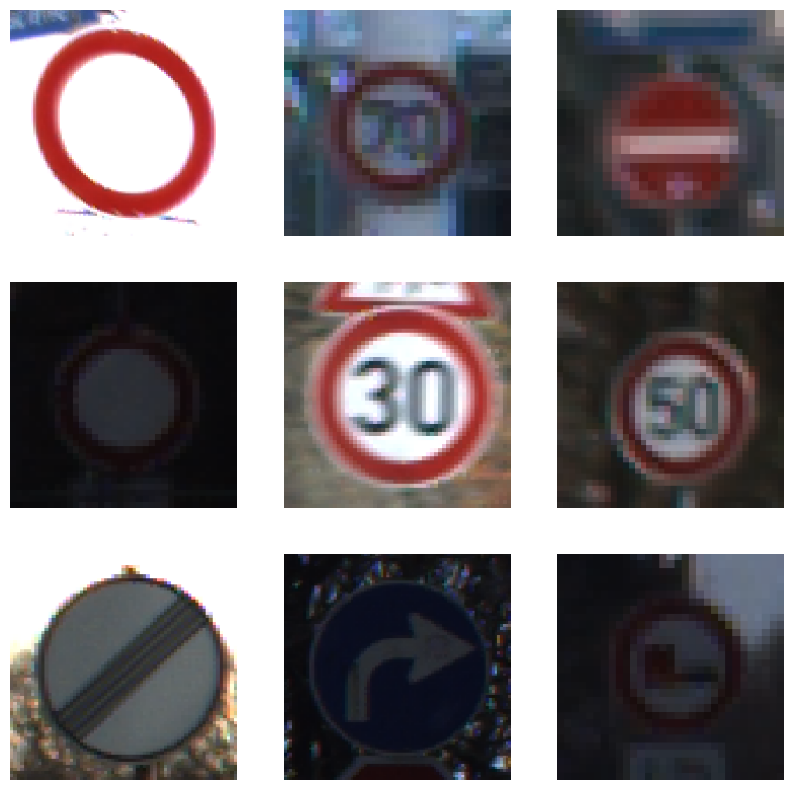

In [ ]:
#Diplay sample images
images,labels=next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [ ]:
#Bild Resnet 50

In [ ]:
base_model=ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
#Creating model
x=base_model.output

x=GlobalAveragePooling2D()(x)

x=Dropout(0.5)(x)

x=Dense(256,activation="relu")(x)

output=Dense(43,activation="softmax")(x)

model=Model(inputs=base_model.input,
            outputs=output)

In [ ]:
#Compiling model

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,123,307 (92.02 MB)

 Trainable params: 535,595 (2.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history=model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=2
)

Epoch 1/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 4513s 5s/step - accuracy: 0.0625 - loss: 3.5685 - val_accuracy: 0.0721 - val_loss: 3.4217
Epoch 2/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 4494s 5s/step - accuracy: 0.0833 - loss: 3.4492 - val_accuracy: 0.0737 - val_loss: 3.3694
Epoch 3/5
483/981 ━━━━━━━━━━━━━━━━━━━━ 30:47 4s/step - accuracy: 0.0922 - loss: 3.4193

In [ ]:
#Accuracy Graph
plt.plot(history.history["accuracy"],label="Training")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.show()

In [ ]:
#Loss graph

In [ ]:
plt.plot(history.history["accuracy"],label="Training")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.show()

In [ ]:
#Evaluate model
loss,accuracy=model.evaluate(validation_generator)

print("Validation Loss :",loss)

print("Validation Accuracy :",accuracy)

In [ ]:
#Saving the model

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("TrafficSign_ResNet50.keras")

print("Model Loaded Successfully")

In [ ]:
#Predict new images

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/test_image.png"

image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

image = cv2.resize(image,(224,224))

image = image.astype("float32")/255.0

image = np.expand_dims(image,axis=0)

prediction = model.predict(image)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

print("Predicted Class :",predicted_class)
print("Confidence :",confidence)

In [ ]:
#Show prediction on images
image = cv2.imread(image_path)

image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

display_image = cv2.resize(image,(300,300))

test = cv2.resize(image,(224,224))

test = test/255.0

test = np.expand_dims(test,axis=0)

prediction = model.predict(test)

predicted_class = np.argmax(prediction)

plt.imshow(display_image)
plt.title(f"Predicted Class : {predicted_class}")
plt.axis("off")
plt.show()